<div style="background:linear-gradient(135deg,#1565c0,#0d47a1);padding:28px 24px;border-radius:8px;margin-bottom:16px;">
<h1 style="color:white;font-size:22px;font-weight:700;margin:0 0 8px;">Reinforcement Learning &amp; Q-Learning Workshop — ABRHS Research Club</h1>
<p style="color:rgba(255,255,255,0.8);font-size:14px;margin:0;">ABRHS Research Club · Q-Learning: From Zero to Reinforcement Learning<br>A structured, hands-on introduction to Reinforcement Learning. No prior ML knowledge required.</p>
</div>

| Section | Topic |
|---------|-------|
| **1** | What is Machine Learning? |
| **2** | The Q-Table — the agent's memory |
| **3** | The Bellman Equation |
| **4** | Exploration vs Exploitation |
| **5** | The Full Algorithm |
| **6** | Live Training Demonstration |
| **7** | Full Python Implementation |

---

> **About this notebook:** This tutorial teaches Reinforcement Learning from the ground up, using Q-Learning as the concrete algorithm. Section 1 covers the foundational concepts every RL problem shares. Sections 2–7 build the algorithm step by step until a fully working Python implementation is complete.


In [8]:
# Dependencies — run this cell first
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import Image, display, HTML

# Reproducibility
random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.facecolor':   '#f9f9f9',
})
print("Libraries loaded.")


Libraries loaded.


<div style="background:#1565c0;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">1</span><span style="font-size:16px;font-weight:600;color:white;">What is Machine Learning?</span></div>


---
## Section 1 — What is Machine Learning?

This tutorial is about **Q-Learning** — a Reinforcement Learning algorithm.  
Before writing a single line of it, three concepts must be established in order:

1. What machine learning is
2. What reinforcement learning is
3. What vocabulary every RL problem shares

---

### Conventional Programming vs Machine Learning

In conventional programming, a developer writes explicit rules: *"if condition X, perform action Y."*  
The program follows those rules exactly and cannot go beyond them.

**Machine learning** takes a different approach. Instead of rules being written by hand,  
the program **learns rules from experience** — either by analysing data, or by trying actions and observing what happens.

> **Analogy:** Think about training a dog. When the dog sits on command, you give it a treat — that is a positive reward.  
> When it jumps on the furniture, you say "no" — that is a penalty. You never hand the dog a rulebook.  
> Over many repetitions, it determines on its own which behaviours lead to rewards and which lead to corrections.  
> Machine learning works on the same principle — the program learns from a feedback signal rather than from explicit instructions.

---
### The Three Branches of Machine Learning

Machine learning is divided into three main branches. Q-Learning belongs to the third — **Reinforcement Learning**.


In [9]:
# The three branches of machine learning
ml_types = {
    "Supervised Learning":   "Learns from labelled examples. Correct answer provided for each training input.",
    "Unsupervised Learning":  "Discovers hidden structure in data. No labels or correct answers provided.",
    "Reinforcement Learning": "Learns through interaction. Receives reward or penalty signals. ← This tutorial",
}
for name, desc in ml_types.items():
    print(f"{name}:")
    print(f"  {desc}\n")


Supervised Learning:
  Learns from labelled examples. Correct answer provided for each training input.

Unsupervised Learning:
  Discovers hidden structure in data. No labels or correct answers provided.

Reinforcement Learning:
  Learns through interaction. Receives reward or penalty signals. ← This tutorial



### The landscape: from programming to Q-Learning

The diagram below shows where Q-Learning and Deep Q-Learning sit within the broader field.

```mermaid
flowchart TD
    A["Conventional Programming\n─────────────────────\nHand-written rules and logic"]
    B["Machine Learning\n─────────────────────\nLearns rules from experience"]
    C["Supervised Learning\n─────────────────\nLabelled examples"]
    D["Unsupervised Learning\n─────────────────\nHidden patterns"]
    E["Reinforcement Learning\n─────────────────\nReward signals"]
    F["Q-Learning\n─────────────────\nTabular · this tutorial"]
    G["Deep Q-Learning (DQN)\n─────────────────\nNeural network replaces table"]

    A -. "vs" .-> B
    B --> C
    B --> D
    B --> E
    E --> F
    F --> G

    style A fill:#F1EFE8,stroke:#5F5E5A,color:#2C2C2A
    style B fill:#E6F1FB,stroke:#185FA5,color:#042C53
    style C fill:#F1EFE8,stroke:#888780,color:#444441
    style D fill:#F1EFE8,stroke:#888780,color:#444441
    style E fill:#E6F1FB,stroke:#185FA5,color:#042C53
    style F fill:#E1F5EE,stroke:#0F6E56,color:#04342C
    style G fill:#EEEDFE,stroke:#534AB7,color:#26215C
```


In [10]:
# Render the Mermaid diagram interactively in Jupyter
from IPython.display import display, HTML

mermaid_src = '''
flowchart TD
    A["Conventional Programming<br/>─────────────────────<br/>Hand-written rules and logic"]
    B["Machine Learning<br/>─────────────────────<br/>Learns rules from experience"]
    C["Supervised Learning<br/>─────────────────<br/>Labelled examples"]
    D["Unsupervised Learning<br/>─────────────────<br/>Hidden patterns"]
    E["Reinforcement Learning<br/>─────────────────<br/>Reward signals"]
    F["Q-Learning<br/>─────────────────<br/>Tabular · this tutorial"]
    G["Deep Q-Learning DQN<br/>─────────────────<br/>Neural network replaces table"]
    A -. vs .-> B
    B --> C
    B --> D
    B --> E
    E --> F
    F --> G
    style A fill:#F1EFE8,stroke:#5F5E5A,color:#2C2C2A
    style B fill:#E6F1FB,stroke:#185FA5,color:#042C53
    style C fill:#F1EFE8,stroke:#888780,color:#444441
    style D fill:#F1EFE8,stroke:#888780,color:#444441
    style E fill:#E6F1FB,stroke:#185FA5,color:#042C53
    style F fill:#E1F5EE,stroke:#0F6E56,color:#04342C
    style G fill:#EEEDFE,stroke:#534AB7,color:#26215C
'''

display(HTML(f"""
<script src='https://cdn.jsdelivr.net/npm/mermaid@11/dist/mermaid.min.js'></script>
<div class='mermaid' style='max-width:580px;margin:12px 0;'>{mermaid_src}</div>
<script>
  if(typeof mermaid !== 'undefined'){{
    mermaid.initialize({{startOnLoad:true,theme:'base',
      themeVariables:{{fontSize:'13px',
        primaryColor:'#E6F1FB',primaryTextColor:'#042C53',
        primaryBorderColor:'#185FA5',lineColor:'#888780'}}}});
  }}
</script>
"""))


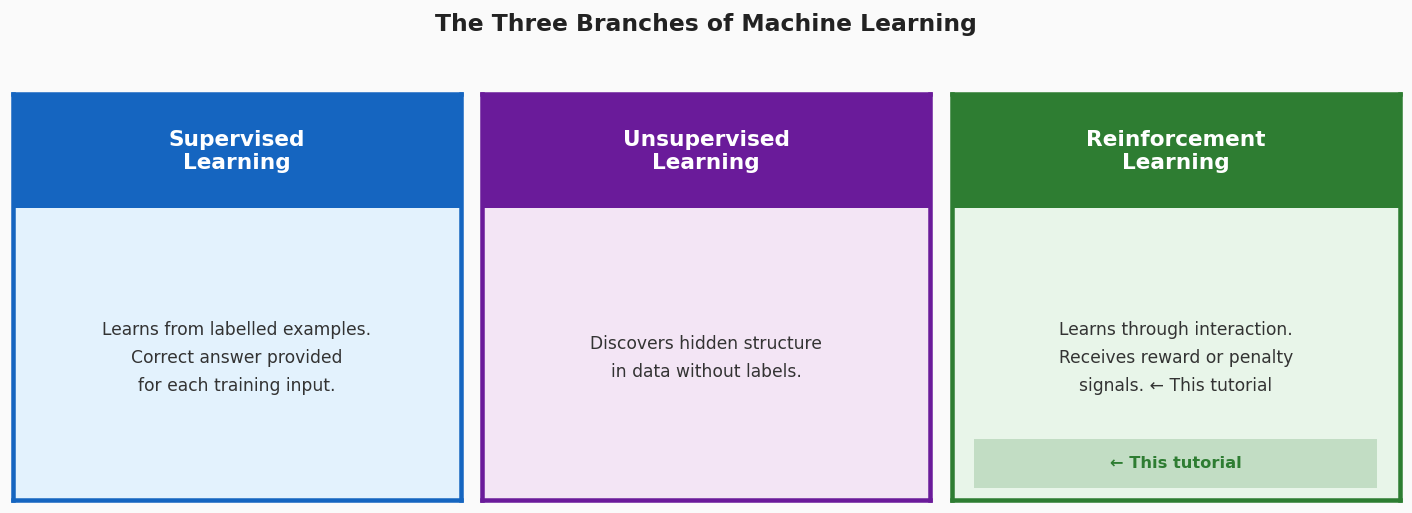

In [11]:
display(Image(filename='assets/ml_types.png'))

---
### Reinforcement Learning in Detail

In Reinforcement Learning, a program called an **agent** is placed inside an **environment**.  
The agent takes actions, and the environment responds with a new situation and a numerical **reward** signal —  
positive for good outcomes, negative for bad ones.  
The agent's goal is to learn a strategy that maximises its total reward over time.

Crucially, **no one programs the rules**. The agent discovers them through repeated trial and error.

---


In [12]:
display(HTML('''<div style="background:#fff8e1;border-left:4px solid #e65100;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#e65100">Important:</strong> In this tutorial, an <strong>agent</strong> is simply a program that observes a state and selects an action. This is entirely different from what is called an 'AI agent' or 'agentic AI' in modern products — those refer to large language models that autonomously browse the web, write code, or chain tasks together. The two uses of the word share a name but are distinct concepts. Throughout this tutorial, 'agent' always means the RL definition above.</div>'''))

**Real-world applications of Reinforcement Learning:**

- **AlphaGo** (Google DeepMind) — learned to play Go at a level beyond any human
- **OpenAI Five** — learned to play Dota 2 at a professional competitive level
- **Robotic arms** — trained to grasp and manipulate objects without explicit programming
- **Autonomous vehicles** — learned control policies for lane-keeping and braking through simulation

---
### Five Terms Every RL Problem Uses

Every Reinforcement Learning problem — regardless of complexity — is described using the same five terms.  
These are the vocabulary of the field. They will appear in every section of this tutorial.


In [13]:
# The five core RL vocabulary terms
vocab = [
    ("Agent",       "The learner / decision-maker",
     "Our program that navigates the grid"),
    ("Environment", "The world the agent interacts with",
     "Our 5×5 grid with walls and a goal"),
    ("State",       "A snapshot of the current situation",
     "Which cell the agent currently occupies: e.g. (row 2, col 3) = state 13"),
    ("Action",      "A choice the agent can make",
     "Move Up, Down, Left, or Right"),
    ("Reward",      "A numerical feedback signal",
     "Goal = +10.0 | Wall = -0.5 | Normal step = -0.1"),
]
print(f"{'Term':<14} {'Definition':<38} {'Example in this tutorial'}")
print("-" * 76)
for name, defn, example in vocab:
    print(f"{name:<14} {defn:<38} {example}")


Term           Definition                             Example in this tutorial
----------------------------------------------------------------------------
Agent          The learner / decision-maker           Our program that navigates the grid
Environment    The world the agent interacts with     Our 5×5 grid with walls and a goal
State          A snapshot of the current situation    Which cell the agent currently occupies: e.g. (row 2, col 3) = state 13
Action         A choice the agent can make            Move Up, Down, Left, or Right
Reward         A numerical feedback signal            Goal = +10.0 | Wall = -0.5 | Normal step = -0.1


---
### The RL Loop

These five concepts interact in a cycle that repeats continuously during training.  
Understanding this loop is the foundation of everything that follows.


In [1]:
# The RL loop — pseudocode
if False:
    while not done:
        state            = env.observe()              # 1. Agent observes current state
        action           = agent.select(state)        # 2. Agent selects an action
        reward, next_state = env.step(action)         # 3. Environment responds
        agent.update(state, action, reward)           # 4. Agent updates its knowledge
        state            = next_state                 # 5. Advance to next state


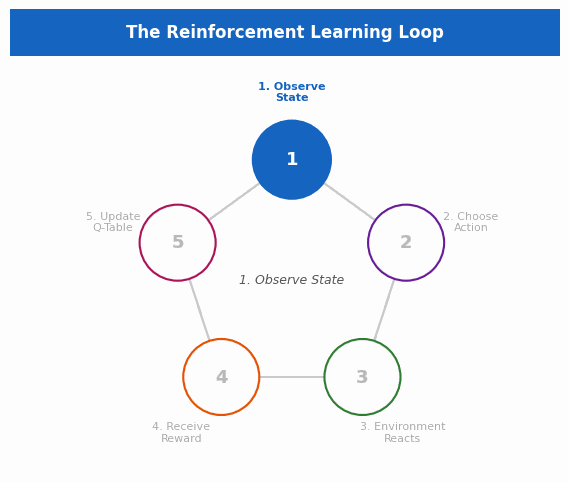

In [15]:
display(Image(filename='assets/rl_loop.gif'))

---
### Foundations Complete — Introducing GridWorld

> All the conceptual vocabulary needed to understand Q-Learning is now in place:  
> **agent, environment, state, action, and reward.**  
> From this point forward, the tutorial moves from theory into implementation.  
> Every section builds directly on the one before it.

---

Throughout this tutorial, the agent operates in a **5×5 grid** called **GridWorld**.  
Its objective is to navigate from the starting cell (top-left, state 0) to the goal cell (bottom-right, state 24)  
while avoiding walls. Each of the 25 cells is one state.

GridWorld is intentionally simple — small enough to visualise clearly,  
but complete enough to demonstrate every aspect of Q-Learning.


In [16]:
# GridWorld environment definition
GRID_H, GRID_W = 5, 5
START = (0, 0)   # top-left corner
GOAL  = (4, 4)   # bottom-right corner

# Walls — these positions are blocked
WALLS = {(1,1), (1,2), (2,3), (3,1), (3,3)}

# Reward structure
REWARD_GOAL = +10.0   # agent reached the goal
REWARD_WALL =  -0.5   # agent attempted to enter a wall (bounced back)
REWARD_STEP =  -0.1   # small cost per step — encourages efficiency

# Available actions: 0=Up, 1=Down, 2=Left, 3=Right
ACTIONS = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}
MOVES   = [(-1,0), (+1,0), (0,-1), (0,+1)]

print(f"Grid dimensions : {GRID_H} × {GRID_W} = {GRID_H*GRID_W} states")
print(f"Number of walls : {len(WALLS)}")
print(f"Number of actions: {len(ACTIONS)}")
print(f"\nState encoding: state = row × {GRID_W} + col")
print(f"  Example: cell (2, 3) → state {2*GRID_W+3}")


Grid dimensions : 5 × 5 = 25 states
Number of walls : 5
Number of actions: 4

State encoding: state = row × 5 + col
  Example: cell (2, 3) → state 13


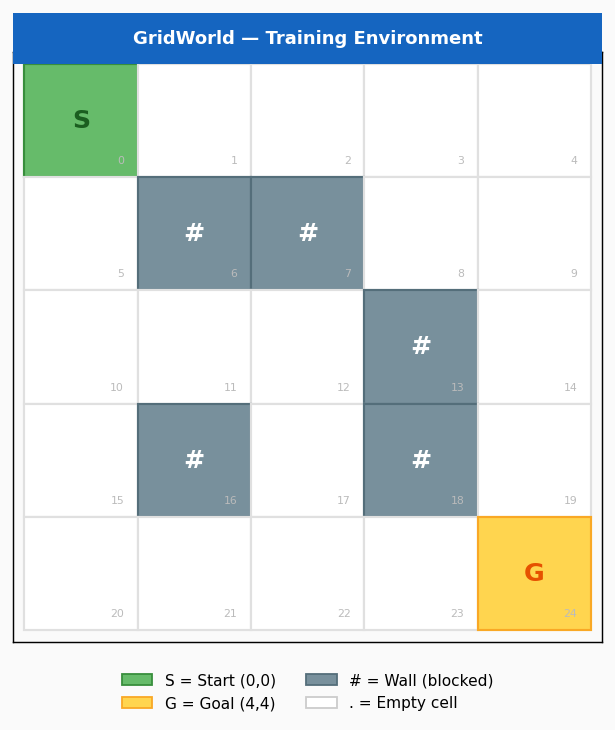

In [17]:
display(Image(filename='assets/gridworld.png'))

In [18]:
display(HTML('''<div style="background:#e3f2fd;border-left:4px solid #1565c0;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#1565c0">Note:</strong> Every empty cell in the grid is a distinct state. State 0 = cell (0,0), state 1 = cell (0,1), ..., state 24 = cell (4,4). Walls occupy positions in the Q-Table but the agent never occupies them — an attempt to enter a wall returns the agent to its previous cell.</div>'''))

---


In [19]:
display(HTML('''<div style="background:#e8f5e9;border-left:4px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#2e7d32">Knowledge Check:</strong> <strong>Knowledge Check:</strong> In GridWorld, what is the state number for cell (3, 2)?<br>Answer: state = 3 × 5 + 2 = <strong>17</strong></div>'''))

In [20]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> <strong>Reinforcement Learning</strong> is a branch of machine learning where an agent learns through interaction with an environment, guided by a reward signal. <strong>Q-Learning</strong> is one specific RL algorithm. Before building it, the necessary vocabulary was established: agent, environment, state, action, and reward.</div>'''))

<div style="background:#2e7d32;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">2</span><span style="font-size:16px;font-weight:600;color:white;">The Q-Table — the Agent's Memory</span></div>


---
## Section 2 — The Q-Table: The Agent's Memory

The agent interacts with the environment over many episodes.  
Each episode produces experiences: which states were visited, which actions were taken, and what rewards were received.  
The agent needs somewhere to store and use that knowledge. That structure is called the **Q-Table**.

The Q-Table is a matrix where each entry records the **expected total future reward**  
for taking a specific action from a specific state.  
As training progresses, these values become more accurate and the agent's decision-making improves.

> **Analogy:** Consider learning a new route through a city. The first time you navigate it, you have no information.  
> Each attempt — including wrong turns and dead ends — builds up your mental map.  
> After enough attempts, you know which turns lead somewhere useful and which do not.  
> The Q-Table is the agent's equivalent of that map, stored as a table of numbers.

---
### Structure of the Q-Table

- Each **row** represents a state (one cell in the grid)
- Each **column** represents an action (Up, Down, Left, Right)
- Each **entry** is a Q-value — the estimated total future reward for taking that action from that state

A **high Q-value** indicates the action is expected to lead to substantial reward from this state.  
A **negative Q-value** indicates the action is expected to produce a poor outcome.


In [21]:
# Step 1: Create a blank Q-Table
# All zeros = the agent has no knowledge yet

NUM_STATES  = 25   # one for each cell in the 5×5 grid
NUM_ACTIONS =  4   # Up, Down, Left, Right

Q = np.zeros((NUM_STATES, NUM_ACTIONS))

print(f"Q-table shape : {Q.shape}")
print(f"  {NUM_STATES} rows    = {NUM_STATES} states")
print(f"  {NUM_ACTIONS} columns = {NUM_ACTIONS} actions (Up, Down, Left, Right)")
print(f"\nFirst 4 rows (states 0–3):")
print(f"  {'State':<10} {'Up':>8} {'Down':>8} {'Left':>8} {'Right':>8}")
print(f"  {'-'*46}")
for i in range(4):
    print(f"  State {i:<4}  {Q[i][0]:>8.2f} {Q[i][1]:>8.2f} {Q[i][2]:>8.2f} {Q[i][3]:>8.2f}")


Q-table shape : (25, 4)
  25 rows    = 25 states
  4 columns = 4 actions (Up, Down, Left, Right)

First 4 rows (states 0–3):
  State            Up     Down     Left    Right
  ----------------------------------------------
  State 0         0.00     0.00     0.00     0.00
  State 1         0.00     0.00     0.00     0.00
  State 2         0.00     0.00     0.00     0.00
  State 3         0.00     0.00     0.00     0.00


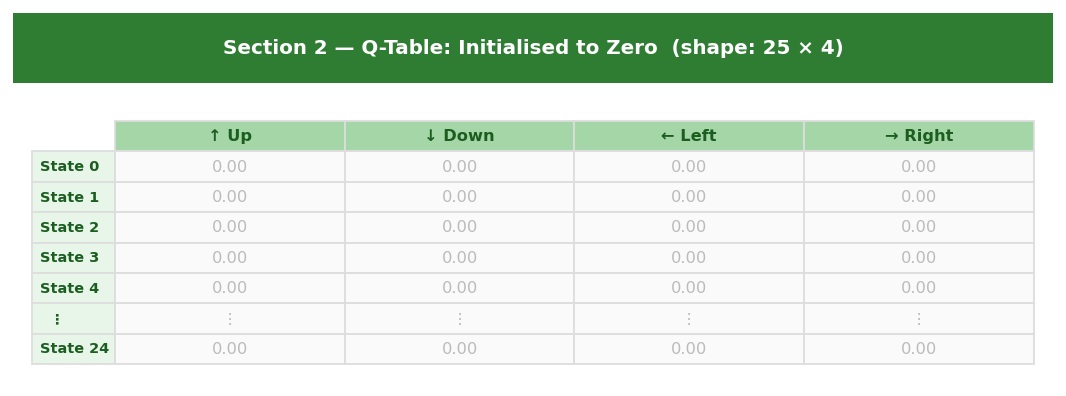

In [22]:
display(Image(filename='assets/qtable_blank.png'))

---
### A Trained Q-Table

After thousands of episodes, the Q-values converge.  
Below is a simplified 4-state example showing what a trained Q-Table looks like.  
The starred (★) entry in each row is the action with the highest Q-value — the one the agent would choose.


In [ ]:
# A trained Q-Table — simplified 4-state example
#               Up      Down    Left   Right
Q_trained = np.array([
    [ 0.10,  0.20,  0.00,  0.55],   # S0 (Start)     → best: Right
    [-0.10,  0.30,  0.10,  0.80],   # S1 (Middle)    → best: Right
    [ 0.30, -0.50,  0.20,  9.00],   # S2 (Near Goal) → best: Right (= Goal!)
    [ 0.00,  0.00,  0.00,  0.00],   # S3 (Goal)      → terminal state
])

action_names = ['Up', 'Down', 'Left', 'Right']
state_names  = ['S0 (Start)', 'S1 (Middle)', 'S2 (Near Goal)', 'S3 (Goal)']

print(f"  {'State':<18} {'Best Action':<14} {'Q-Value'}")
print(f"  {'-'*44}")
for s, row in enumerate(Q_trained):
    if s < 3:
        best = int(np.argmax(row))
        print(f"  {state_names[s]:<18} {action_names[best]:<14} {row[best]:.2f}")
    else:
        print(f"  {state_names[s]:<18} {'(terminal)':14} —")


  State              Best Action    Q-Value
  --------------------------------------------
  S0 (Start)         Right          0.55
  S1 (Middle)        Right          0.80
  S2 (Near Goal)     Right          9.00
  S3 (Goal)          (terminal)     —


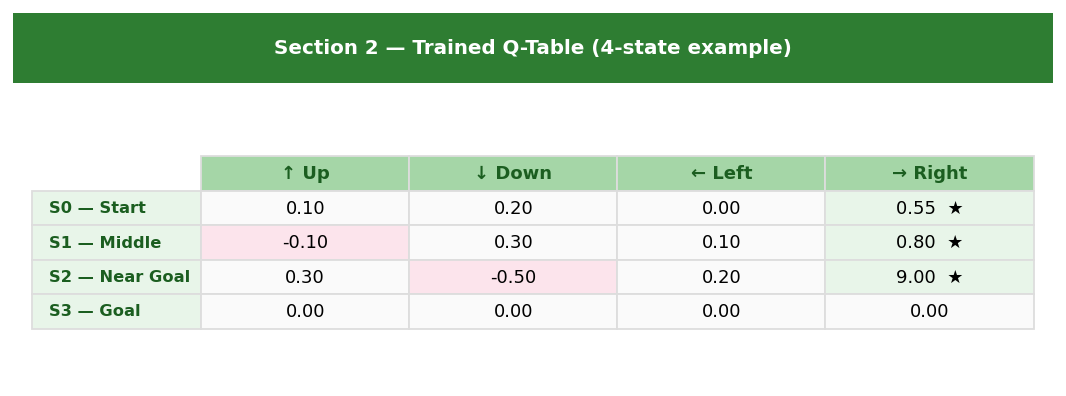

In [ ]:
display(Image(filename='assets/qtable_trained.png'))

In [ ]:
display(HTML('''<div style="background:#fff8e1;border-left:4px solid #e65100;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#e65100">Important:</strong> During training, the agent does not always pick the highest Q-value. It sometimes selects a random action to explore alternatives. The mechanism that controls this is explained in Section 4. After training is complete, the agent always selects the action with the highest Q-value (the greedy policy).</div>'''))

In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The <strong>Q-Table</strong> is a matrix — one row per state, one column per action. Each number estimates the total future reward for that (state, action) pair. It is initialised to zero and updated with every experience. To make a decision after training, the agent selects the action with the highest value in its current row.</div>'''))

<div style="background:#6a1b9a;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">3</span><span style="font-size:16px;font-weight:600;color:white;">The Bellman Equation</span></div>


---
## Section 3 — The Bellman Equation: How to Update the Q-Table

The Q-Table is initialised to zeros. The central question of Q-Learning is: **how exactly do its values get updated?**

After every step the agent takes, it uses its experience to ask:  
*"Was my previous estimate for this (state, action) pair accurate? If not, how should I correct it?"*

The formula that governs this correction is known as the **Bellman equation**,  
after mathematician Richard Bellman, who formalised it in the 1950s. It is built up in three steps.

---
### Step 1 — Correcting an Estimate

Suppose the agent currently believes a certain action is worth 2 points.  
After taking it, the observed outcome is worth 5 points. The most direct correction would be:

```
new estimate = old estimate + (actual − old estimate)
```

Applying this fully would mean a single experience completely overwrites all prior learning — too unstable.  
To control the rate of change, a **learning rate (α, "alpha")** is introduced.

---
### Step 2 — Introducing the Learning Rate α

```
new Q = old Q + α × (actual − old Q)
```

| α value | Effect |
|---------|--------|
| **1.0** | Replace the old estimate entirely (one bad experience destroys all prior learning) |
| **0.0** | Never update (the agent learns nothing) |
| **0.1** | Move 10% toward the new estimate each time (typical starting value) |

---
### Step 3 — Defining the "Actual" Value

The "actual" value is not simply the immediate reward.  
It is the reward *plus* an estimate of the best total return available from the next state onward:

```
actual = R + γ × max Q(next state)
```

- **R** — the immediate reward received
- **γ (gamma)** — the discount factor (0 to 1), controlling how much weight is given to future rewards
- **max Q(next state)** — the highest Q-value available in the state moved into

> **Why discount future rewards?**  
> A reward available now is more certain than one that depends on many future steps going correctly.  
> With γ = 0.9, a reward one step away is worth 90% of its face value; two steps away is 81%; and so on.  
> Setting γ closer to 1 makes the agent plan further ahead; closer to 0 focuses it on immediate rewards only.

---
### The Complete Bellman Equation

Combining all three steps:


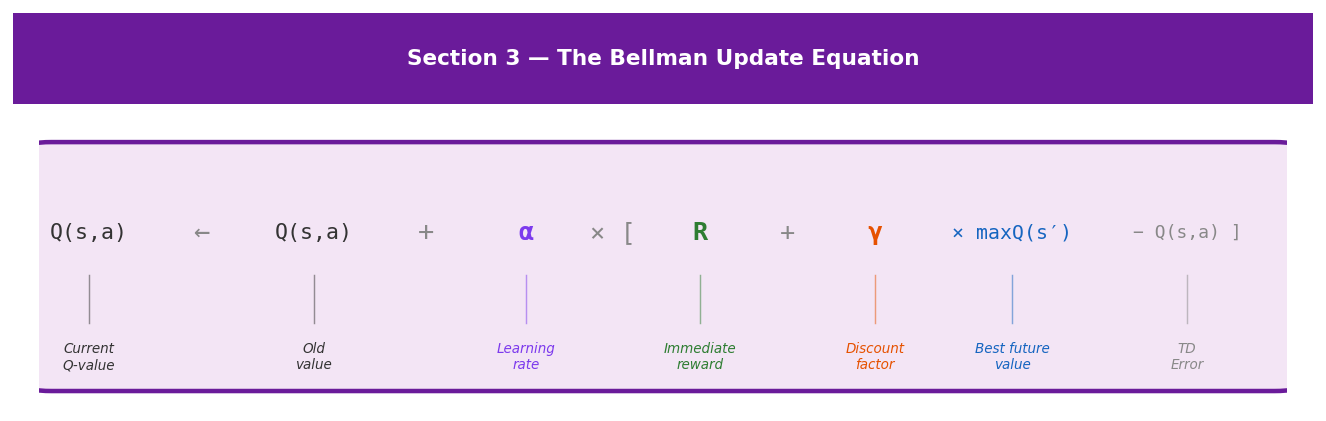

In [ ]:
display(Image(filename='assets/bellman_equation.png'))

In plain terms:  
*Update the Q-value for this (state, action) pair by moving it toward the immediate reward received  
plus the discounted best future value available from the next state.*


In [ ]:
def bellman_update(Q, state, action, reward, next_state,
                   alpha=0.1, gamma=0.9):
    """
    Apply the Bellman update to Q[state][action].
    
    Parameters
    ----------
    alpha : float — learning rate  (how fast to update, 0–1)
    gamma : float — discount factor (how much to value future rewards, 0–1)
    """
    best_future = np.max(Q[next_state])               # max Q(s', a')
    td_target   = reward + gamma * best_future        # target value
    td_error    = td_target - Q[state][action]        # how wrong we are
    Q[state][action] += alpha * td_error              # apply correction
    return Q


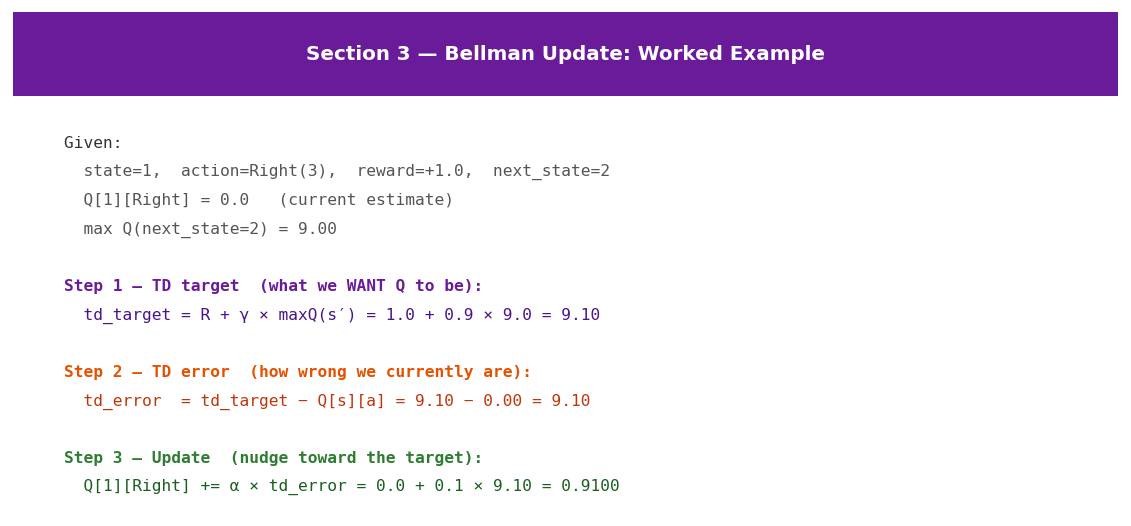

In [ ]:
display(Image(filename='assets/bellman_worked.png'))

In [ ]:
# Verify the worked example in Python
Q_ex = np.zeros((4, 4))
Q_ex[2][3] = 9.0   # state 2 already has a known Q-value for Right

print(f"Before update: Q[1][Right] = {Q_ex[1][3]:.4f}")
Q_ex = bellman_update(Q_ex, state=1, action=3, reward=1.0, next_state=2)
print(f"After update:  Q[1][Right] = {Q_ex[1][3]:.4f}")
print(f"\nStep by step (α=0.1, γ=0.9):")
print(f"  best_future = max(Q[2]) = 9.00")
print(f"  td_target   = 1.0 + 0.9 × 9.0 = {1.0 + 0.9*9.0:.2f}")
print(f"  td_error    = 9.1 − 0.0 = 9.10")
print(f"  new Q       = 0.0 + 0.1 × 9.1 = {0.1*(1.0+0.9*9.0):.4f}")


Before update: Q[1][Right] = 0.0000
After update:  Q[1][Right] = 0.9100

Step by step (α=0.1, γ=0.9):
  best_future = max(Q[2]) = 9.00
  td_target   = 1.0 + 0.9 × 9.0 = 9.10
  td_error    = 9.1 − 0.0 = 9.10
  new Q       = 0.0 + 0.1 × 9.1 = 0.9100


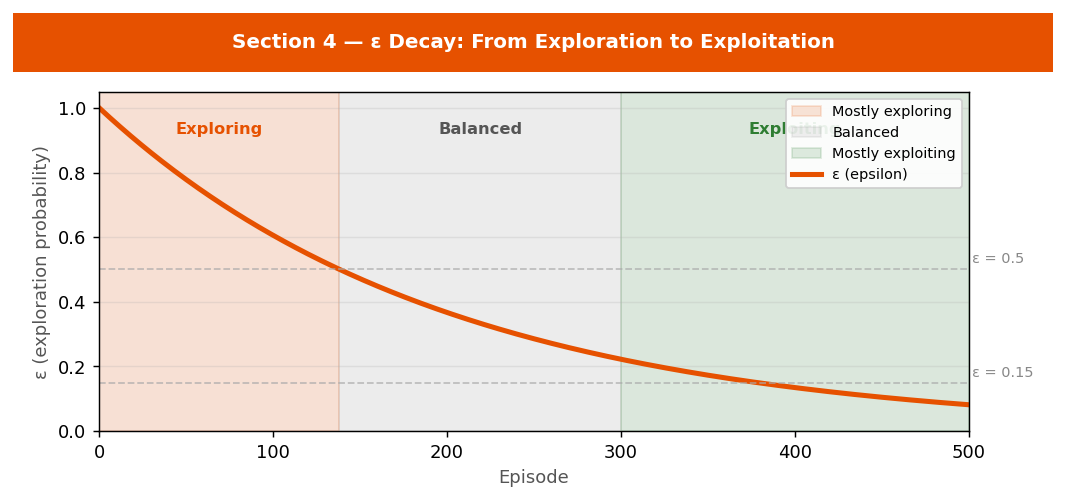

In [ ]:
display(Image(filename='assets/epsilon_decay.png'))

In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The Bellman equation defines precisely how Q-values are updated after each experience. It combines the immediate reward with a discounted estimate of future value. α determines the speed of convergence. γ determines how far ahead the agent plans. Each update brings the Q-Table closer to accurately representing the optimal strategy.</div>'''))

<div style="background:#e65100;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">4</span><span style="font-size:16px;font-weight:600;color:white;">Exploration vs Exploitation</span></div>


---
## Section 4 — Exploration vs Exploitation

There is a problem that the Q-Table alone does not solve.  
If the agent always selects the action with the highest current Q-value,  
it will quickly settle into a fixed strategy based on its earliest experiences.  
It may never discover that a better path exists, simply because it never tried it.

This is known as the **exploration-exploitation tradeoff** — one of the central challenges in Reinforcement Learning.

> **Analogy:** Consider always choosing the same restaurant because it is reliably good.  
> That is exploitation — using known information to get a reliable outcome.  
> But a better restaurant may exist nearby that you have never visited.  
> Discovering it would require exploration — trying something unfamiliar at the risk of a worse outcome.  
> Reinforcement Learning faces the same tradeoff at every step.

---
### The ε-Greedy Policy

The standard solution is a probabilistic rule called **ε-greedy** (epsilon-greedy).  
At every step, the agent draws a random number between 0 and 1:

- If it is less than **ε** → take a **random action** (explore)
- Otherwise → take the action with the **highest Q-value** in the current state (exploit)

Training begins with ε = 1.0 (the agent acts entirely at random).  
ε is then reduced after each episode — **ε-decay** — so that as the Q-Table becomes reliable, the agent increasingly exploits it.


In [ ]:
def choose_action(Q, state, epsilon):
    """
    ε-greedy action selection.
    
    With probability epsilon  → explore  (random action)
    With probability 1-epsilon → exploit (greedy action)
    """
    if random.random() < epsilon:
        return random.randint(0, 3)     # explore
    else:
        return int(np.argmax(Q[state])) # exploit

# ε-decay schedule
epsilon_start = 1.0
epsilon_min   = 0.01
epsilon_decay = 0.995

def epsilon_at(episode):
    # Compute epsilon at a given episode number
    return max(epsilon_min, epsilon_start * epsilon_decay ** episode)

print(f"  {'Episode':<12} {'Epsilon':>10}   Phase")
print(f"  {'-'*40}")
for ep in [1, 100, 200, 300, 500]:
    eps = epsilon_at(ep)
    phase = ("Mostly exploring"  if eps > 0.5  else
             "Balanced"          if eps > 0.15 else
             "Mostly exploiting")
    print(f"  {ep:<12} {eps:>10.3f}   {phase}")


  Episode      Epsilon   Phase
  ----------------------------------------
  1              1.000   Mostly exploring
  100            0.606   Mostly exploring
  200            0.368   Balanced
  300            0.223   Balanced
  500            0.082   Mostly exploiting


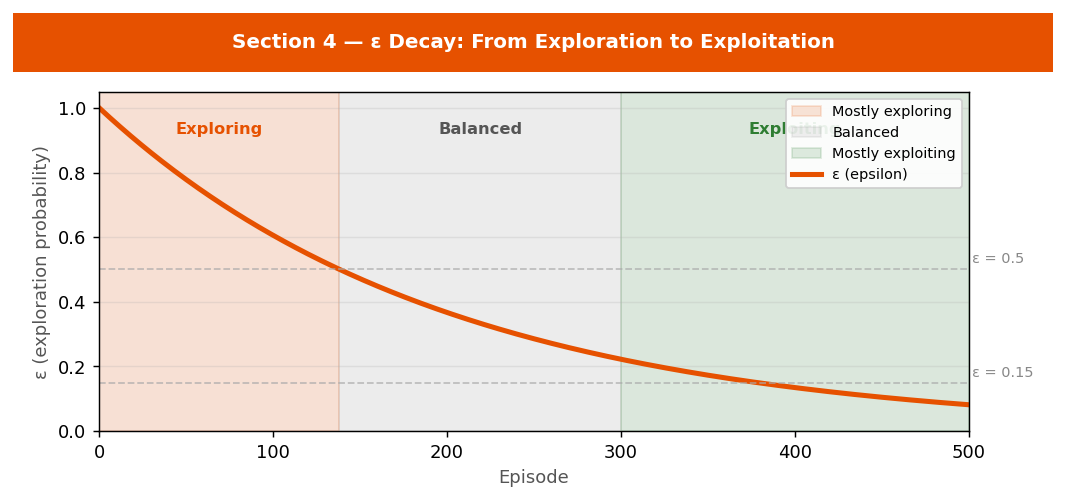

In [ ]:
display(Image(filename='assets/epsilon_decay.png'))

In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The <strong>exploration-exploitation tradeoff</strong> is a fundamental challenge in Reinforcement Learning. Q-Learning addresses it with the <strong>ε-greedy policy</strong>: with probability ε the agent explores (random action); otherwise it exploits (best known action). ε starts at 1 — when the Q-Table holds no useful information — and decays toward a small minimum as training progresses and the table becomes reliable.</div>'''))

<div style="background:#37474f;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">5</span><span style="font-size:16px;font-weight:600;color:white;">The Full Algorithm</span></div>


---
## Section 5 — The Full Algorithm

All four components are now in place:

| Component | Role |
|-----------|------|
| **The RL loop** | Agent, environment, state, action, reward |
| **Q-Table** | Stores estimated value of every (state, action) pair |
| **The Bellman equation** | Updates Q-values after each step |
| **ε-greedy** | Balances exploration and exploitation |

This section combines them into the complete Q-Learning algorithm.

---


In [ ]:
# Environment step function
def env_step(r, c, action):
    """
    Execute one action. Returns (new_row, new_col, reward, done).
    
    If the agent moves into a wall, it bounces back to its current cell.
    If it reaches the goal, the episode ends.
    """
    dr, dc = MOVES[action]
    nr = max(0, min(GRID_H - 1, r + dr))
    nc = max(0, min(GRID_W - 1, c + dc))

    if (nr, nc) in WALLS:  return r,  c,  REWARD_WALL, False  # bounce back
    if (nr, nc) == GOAL:   return nr, nc, REWARD_GOAL, True   # episode ends
    return nr, nc, REWARD_STEP, False                          # normal step


In [ ]:
def q_learning(num_episodes=500, alpha=0.1, gamma=0.9,
               epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
    """
    Complete Q-Learning algorithm.

    Parameters
    ----------
    num_episodes  : int   — number of training episodes
    alpha         : float — learning rate
    gamma         : float — discount factor
    epsilon       : float — initial exploration probability
    epsilon_min   : float — minimum exploration probability
    epsilon_decay : float — multiplicative decay applied after each episode

    Returns
    -------
    Q             : np.ndarray — trained Q-Table (shape: 25 × 4)
    rewards_log   : list       — total reward per episode
    """
    # STEP 1 — Initialise Q-Table
    Q = np.zeros((GRID_H * GRID_W, len(ACTIONS)))
    rewards_log = []

    for episode in range(num_episodes):

        # STEP 2 — Reset: agent returns to start
        row, col = START
        total_reward = 0
        done = False

        while not done:
            state = row * GRID_W + col  # encode (row, col) as a single integer

            # STEP 3 — Select action using ε-greedy policy
            if random.random() < epsilon:
                action = random.randint(0, len(ACTIONS) - 1)  # explore
            else:
                action = int(np.argmax(Q[state]))              # exploit

            # STEP 4 — Execute action and observe outcome
            next_row, next_col, reward, done = env_step(row, col, action)
            next_state = next_row * GRID_W + next_col

            # STEP 5 — Apply Bellman update
            Q[state][action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state][action]
            )

            row, col = next_row, next_col
            total_reward += reward

        # STEP 6 — Decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_log.append(total_reward)

    return Q, rewards_log

print("q_learning() defined. Proceed to Section 6 to run it.")


q_learning() defined. Proceed to Section 6 to run it.


In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The complete Q-Learning algorithm consists of six steps executed repeatedly: <strong>Initialise → Reset → ε-greedy selection → Step → Bellman update → Decay ε</strong>. Over many episodes, the Q-Table converges toward an accurate representation of the optimal policy — the best action to take from every state.</div>'''))

<div style="background:#00796b;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">6</span><span style="font-size:16px;font-weight:600;color:white;">Live Training Demonstration</span></div>


---
## Section 6 — Live Training Demonstration

This section runs the Q-Learning algorithm and visualises what happens as training progresses.  
The animated GIF below captures snapshots at episodes 1, 10, 30, 60, 100, 150, 200, and 300.

Each frame shows:
- **Left** — the policy grid: the best action in each cell according to the current Q-Table
- **Right** — the reward curve: total reward per episode (teal bars) and rolling average (orange line)

Early episodes are poor and erratic. As training progresses, the policy improves and the reward stabilises.


In [ ]:
# Run training
print("Training Q-Learning agent on GridWorld...")
Q_trained, reward_history = q_learning(
    num_episodes  = 300,
    alpha         = 0.3,
    gamma         = 0.9,
    epsilon       = 1.0,
    epsilon_min   = 0.01,
    epsilon_decay = 0.995,
)
print(f"Training complete.")
print(f"  Average reward, episodes   1–50 : {np.mean(reward_history[:50]):.2f}")
print(f"  Average reward, episodes 251–300: {np.mean(reward_history[250:]):.2f}")


Training Q-Learning agent on GridWorld...
Training complete.
  Average reward, episodes   1–50 : -3.47
  Average reward, episodes 251–300:  7.43


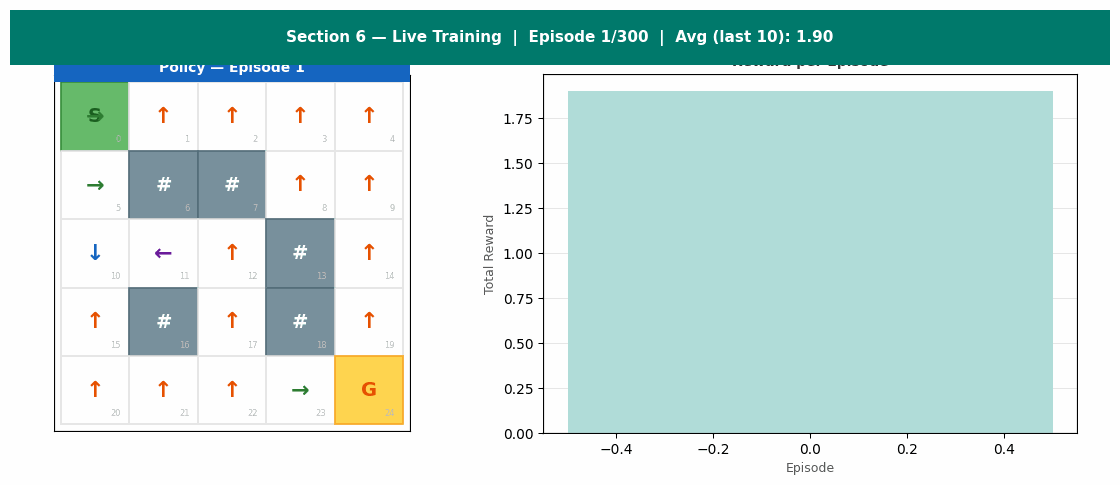

In [ ]:
display(Image(filename='assets/training.gif'))

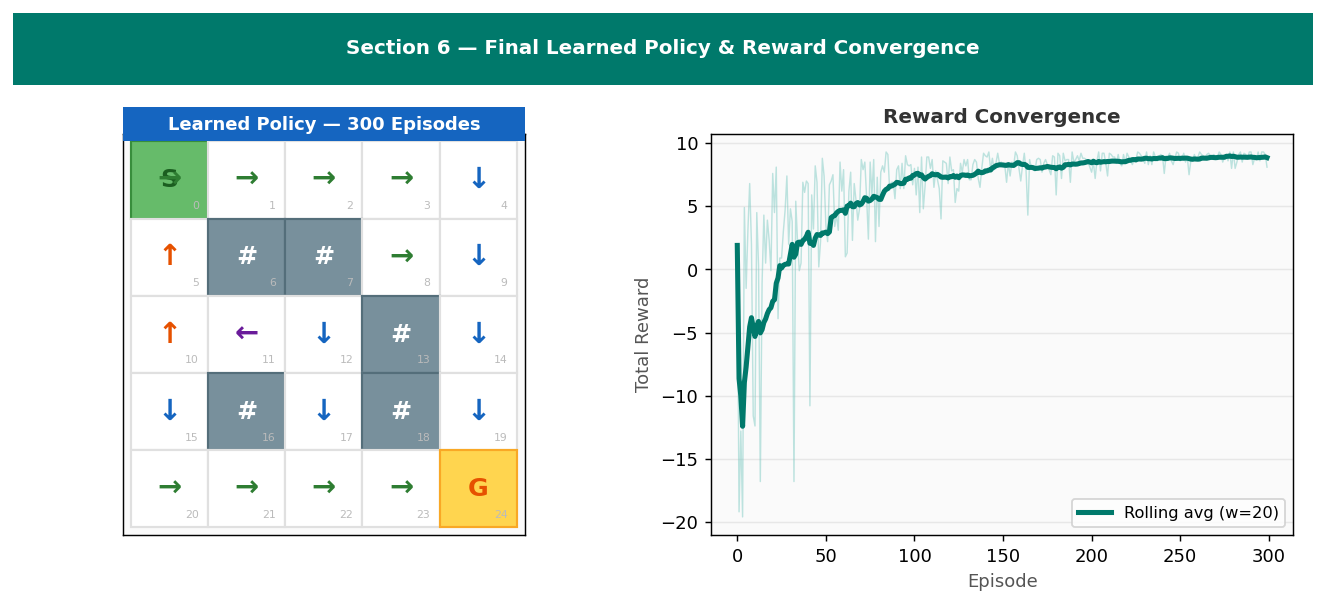

In [ ]:
display(Image(filename='assets/final_policy.png'))

In [ ]:
# Print the learned policy as a grid of arrows
arrows = ['↑', '↓', '←', '→']
print("Learned policy after 300 episodes:\n")
print("     Col 0  Col 1  Col 2  Col 3  Col 4")
print("    " + "-" * 36)
for row in range(GRID_H):
    line = f"Row {row} |"
    for col in range(GRID_W):
        if   (row, col) in WALLS: line += "  #   "
        elif (row, col) == GOAL:  line += "  G   "
        else:
            best = int(np.argmax(Q_trained[row * GRID_W + col]))
            line += f"  {arrows[best]}   "
    print(line)


Learned policy after 300 episodes:

     Col 0  Col 1  Col 2  Col 3  Col 4
    ------------------------------------
Row 0 |  →     →     →     →     ↓   
Row 1 |  →     #     #     →     ↓   
Row 2 |  →     →     →     #     ↓   
Row 3 |  ↑     #     →     #     ↓   
Row 4 |  →     →     →     →     G   


In [ ]:
display(HTML('''<div style="background:#e3f2fd;border-left:4px solid #1565c0;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#1565c0">Note:</strong> Notice how the reward curve improves over time. Early on, the agent wanders randomly and rarely reaches the goal. By episode 300, it has learned a reliable path and consistently achieves high reward. This convergence is the result of thousands of Bellman updates accumulating in the Q-Table.</div>'''))

<div style="background:#ad1457;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">7</span><span style="font-size:16px;font-weight:600;color:white;">Full Python Implementation</span></div>


---
## Section 7 — Full Python Implementation

Below is the complete, self-contained implementation.  
It can be run locally with Python 3 and NumPy (`pip install numpy`).  
Every concept from this tutorial is present in this code.


In [ ]:
"""
Q-Learning on GridWorld — Complete Implementation
=================================================
Dependencies: numpy

Usage:
    python qlearning.py
"""
import numpy as np
import random

# ─── 1. ENVIRONMENT ──────────────────────────────────────────────
GRID_H, GRID_W = 5, 5
WALLS  = {(1,1), (1,2), (2,3), (3,1), (3,3)}
START  = (0, 0)
GOAL   = (4, 4)
MOVES  = [(-1,0), (+1,0), (0,-1), (0,+1)]   # Up Down Left Right

REWARD_GOAL = +10.0
REWARD_WALL =  -0.5
REWARD_STEP =  -0.1

def env_step(r, c, action):
    """Execute one action. Returns (new_row, new_col, reward, done)."""
    dr, dc = MOVES[action]
    nr = max(0, min(GRID_H - 1, r + dr))
    nc = max(0, min(GRID_W - 1, c + dc))
    if (nr, nc) in WALLS:  return r,  c,  REWARD_WALL, False
    if (nr, nc) == GOAL:   return nr, nc, REWARD_GOAL, True
    return nr, nc, REWARD_STEP, False

# ─── 2. Q-LEARNING ───────────────────────────────────────────────
def train(num_episodes=500, alpha=0.1, gamma=0.9,
          epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
    """Train a Q-Learning agent on GridWorld."""
    Q       = np.zeros((GRID_H * GRID_W, 4))
    history = []

    for episode in range(num_episodes):
        r, c  = START
        total = 0

        for _ in range(200):   # max steps per episode
            s = r * GRID_W + c

            # ε-greedy action selection
            if random.random() < epsilon:
                a = random.randint(0, 3)        # explore
            else:
                a = int(np.argmax(Q[s]))        # exploit

            # step and observe
            nr, nc, reward, done = env_step(r, c, a)
            ns = nr * GRID_W + nc

            # Bellman update
            Q[s][a] += alpha * (reward + gamma * np.max(Q[ns]) - Q[s][a])

            r, c   = nr, nc
            total += reward
            if done:
                break

        # decay exploration
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        history.append(total)

    return Q, history

# ─── 3. RUN AND REPORT ───────────────────────────────────────────
random.seed(42)
np.random.seed(42)

Q_final, history = train(num_episodes=500)

print(f"Training complete — 500 episodes")
print(f"  Avg reward, first 50 episodes : {np.mean(history[:50]):.2f}")
print(f"  Avg reward, last  50 episodes : {np.mean(history[-50:]):.2f}")

# Print learned policy
arrows = ['↑', '↓', '←', '→']
print("\nLearned policy:")
print("     " + "  ".join(f"Col{c}" for c in range(GRID_W)))
for r in range(GRID_H):
    row_str = f"Row{r}  "
    for c in range(GRID_W):
        if   (r, c) in WALLS: row_str += " #   "
        elif (r, c) == GOAL:  row_str += " G   "
        else:
            best = int(np.argmax(Q_final[r * GRID_W + c]))
            row_str += f" {arrows[best]}   "
    print(row_str)


Training complete — 500 episodes
  Avg reward, first 50 episodes : -3.47
  Avg reward, last  50 episodes :  7.43

Learned policy:
     Col0  Col1  Col2  Col3  Col4
Row0   →     →     →     →     ↓  
Row1   →     #     #     →     ↓  
Row2   →     →     →     #     ↓  
Row3   ↑     #     →     #     ↓  
Row4   →     →     →     →     G  


---
## Summary

This tutorial covered Reinforcement Learning from first principles through a complete working implementation.

| Concept | What it does |
|---------|-------------|
| **Agent** | The program that learns and makes decisions |
| **Environment** | The world the agent interacts with |
| **State / Action / Reward** | The vocabulary of every RL problem |
| **Q-Table** | Stores estimated value of every (state, action) pair |
| **Bellman equation** | Updates Q-values using immediate reward + discounted future value |
| **ε-greedy** | Balances exploration of new actions with exploitation of known ones |
| **ε-decay** | Gradually shifts the agent from exploring to exploiting as the Q-Table matures |

The complete algorithm is six steps — **Initialise → Reset → Select → Step → Update → Decay** — repeated for every episode until the Q-Table converges to the optimal policy.

---
*ABRHS Research Club Workshop — Reinforcement Learning & Q-Learning*  
*Companion HTML tutorial: `qlearning-highschool.html`*
